In [1]:
from science_jubilee.machine_session import MachineSession
import matplotlib.pyplot as plt
import time

session = MachineSession.from_env(".env.hardware")

import math
import matplotlib.pyplot as plt

def show_grid(images, C=4, titles=None, size=3):
    R = math.ceil(len(images) / C)
    fig, axes = plt.subplots(R, C, figsize=(C * size, R * size), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        if i < len(images):
            img = plt.imread(images[i]) if isinstance(images[i], str) else images[i]
            ax.imshow(img)
            if titles: ax.set_title(titles[i])
    plt.tight_layout(); plt.show()

No plugin registered for tool 'Inoculator' in slot 0; using base Tool. Install the matching plugin or check the Duet M563 name.
No plugin registered for tool 'Pen' in slot 1; using base Tool. Install the matching plugin or check the Duet M563 name.
No plugin registered for tool 'Test' in slot 2; using base Tool. Install the matching plugin or check the Duet M563 name.
2026-09-25 14:41:01,392 [INFO] Camera response: 200
2026-09-25 14:41:01,392 [INFO] in auto focus mode, the camera will continuously adjust focus automatically
2026-09-25 14:41:01,393 [INFO] Camera response: 200
2026-09-25 14:41:01,393 [INFO] Setting focus mode to auto


In [2]:
session.free_navigator.move_to(x=150, y=150, z=300)

In [3]:
camera=session.camera
x0,x1 = 200, 600
y0, y1 = 700, 1200

In [4]:
camera.get_option("AfMode")

2026-09-25 14:41:03,662 [INFO] Camera option AfMode is 2


2

2026-09-25 14:41:03,682 [INFO] Camera response: 200
2026-09-25 14:41:03,683 [INFO] in auto focus mode, the camera will continuously adjust focus automatically
2026-09-25 14:41:03,683 [INFO] Camera response: 200
2026-09-25 14:41:03,684 [INFO] Setting focus mode to auto


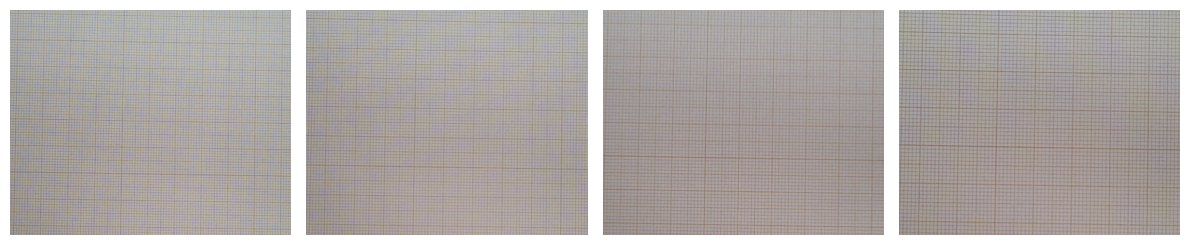

In [5]:
camera.focus_mode("auto")
images = []
for dz in range(0, 12):
    if dz%3==0:
        session.free_navigator.move_to(x=150, y=150, z=300-dz*10)
        time.sleep(2)
        im = camera.get_image()
        images.append(im[x0:x1, y0:y1])
show_grid(images)

2026-09-25 14:41:16,108 [INFO] Camera response: 200
2026-09-25 14:41:16,109 [INFO] in manual mode, use lensPosition parameter to adjust focus
2026-09-25 14:41:16,109 [INFO] Camera response: 200
2026-09-25 14:41:16,109 [INFO] Setting focus mode to manual
2026-09-25 14:41:16,123 [INFO] Camera response: 200
2026-09-25 14:41:16,124 [INFO] Camera response: 200
2026-09-25 14:41:16,124 [INFO] Setting lens position to 0
2026-09-25 14:41:16,301 [INFO] Camera response: 200
2026-09-25 14:41:16,302 [INFO] Camera response: 200
2026-09-25 14:41:16,302 [INFO] Setting lens position to 3
2026-09-25 14:41:16,456 [INFO] Camera response: 200
2026-09-25 14:41:16,456 [INFO] Camera response: 200
2026-09-25 14:41:16,457 [INFO] Setting lens position to 6
2026-09-25 14:41:16,698 [INFO] Camera response: 200
2026-09-25 14:41:16,699 [INFO] Camera response: 200
2026-09-25 14:41:16,699 [INFO] Setting lens position to 9
2026-09-25 14:41:16,885 [INFO] Camera response: 200
2026-09-25 14:41:16,885 [INFO] Camera response

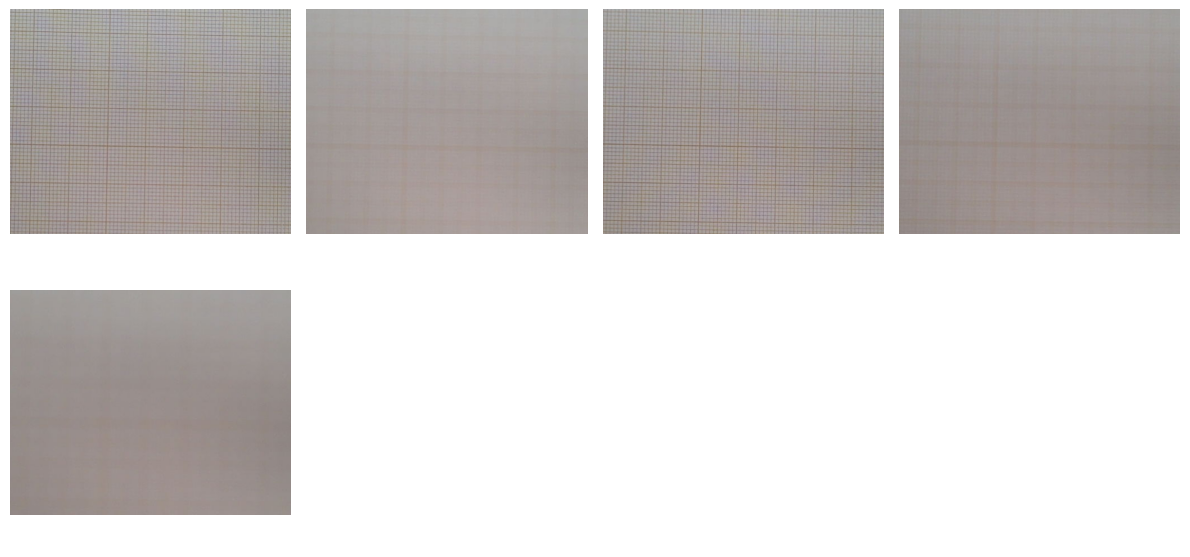

In [6]:
camera.focus_mode("manual")
images = []
for i in range(0, 13):
    if i%3==0:
        camera.lens_position(i)
        im = camera.get_image()
        images.append(im[x0:x1, y0:y1])

show_grid(images)

2026-09-25 14:41:17,270 [INFO] Camera response: 200
2026-09-25 14:41:17,271 [INFO] in single focus mode, the camera will focus once and then hold: use trigger_focus to refocus if needed
2026-09-25 14:41:17,271 [INFO] Camera response: 200
2026-09-25 14:41:17,272 [INFO] Setting focus mode to single
2026-09-25 14:41:19,546 [INFO] Camera option AfMode is 1
2026-09-25 14:41:20,562 [INFO] Camera response: 200
2026-09-25 14:41:22,607 [INFO] Camera response: 200
2026-09-25 14:41:22,608 [INFO] Triggered camera to refocus
2026-09-25 14:41:23,840 [INFO] Camera option AfMode is 1
2026-09-25 14:41:24,864 [INFO] Camera response: 200
2026-09-25 14:41:26,873 [INFO] Camera response: 200
2026-09-25 14:41:26,873 [INFO] Triggered camera to refocus
2026-09-25 14:41:28,096 [INFO] Camera option AfMode is 1
2026-09-25 14:41:29,130 [INFO] Camera response: 200
2026-09-25 14:41:31,140 [INFO] Camera response: 200
2026-09-25 14:41:31,141 [INFO] Triggered camera to refocus
2026-09-25 14:41:32,393 [INFO] Camera opti

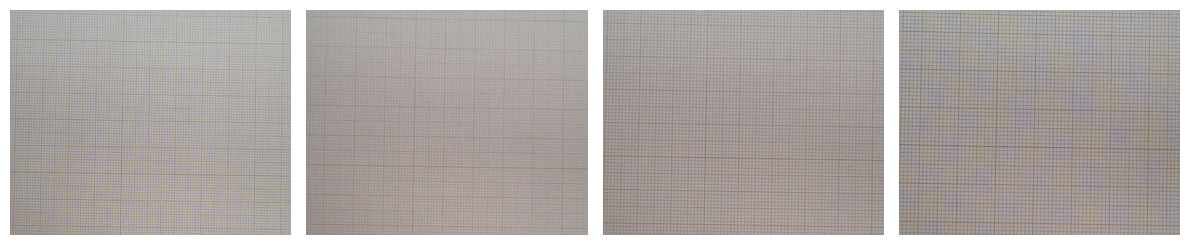

In [7]:
camera.focus_mode("single")
images = []
for dz in range(0, 12):
    if dz%3==0:
        session.free_navigator.move_to(x=150, y=150, z=300-dz*10)

        camera.trigger_focus()

        im = camera.get_image()
        images.append(im[x0:x1, y0:y1])
show_grid(images)